# Churn prediction 
is one of the most popular Big Data use cases in business. It consists of detecting customers who are likely to cancel a subscription to a service.

Although originally a telcom giant thing, this concerns businesses of all sizes, including startups. Now, thanks to prediction services and APIs, predictive analytics are no longer exclusive to big players that can afford to hire teams of data scientists.

As an example of how to use churn prediction to improve your business, let’s consider businesses that sell subscriptions. This can be telecom companies, SaaS companies, and any other company that sells a service for a monthly fee.

There are three possible strategies those businesses can use to generate more revenue: acquire more customers, upsell existing customers, or increase customer retention. All the efforts made as part of one of the strategies have a cost, and what we’re ultimately interested in is the return on investment: the ratio between the extra revenue that results from these efforts and their cost[[**1**](https://neilpatel.com/blog/improve-by-predicting-churn/#:~:text=Churn%20prediction%20is%20one%20of,a%20subscription%20to%20a%20service.&text=This%20can%20be%20telecom%20companies,service%20for%20a%20monthly%20fee.)]

![](https://miro.medium.com/max/844/1*MyKDLRda6yHGR_8kgVvckg.png)

In this study, we tried to predict Customer Churn using Random Forest and Naive Bayesian classifier.

Variable Prediction:
1.    CustomerID                   
1.   MonthlyRevenue             
1.     MonthlyMinutes            
1.     TotalRecurringCharge      
1.     DirectorAssistedCalls      
1.     OverageMinutes             
1.    RoamingCalls              
1.    PercChangeMinutes         
1.     PercChangeRevenues        
1.    DroppedCalls               
1.    BlockedCalls               
1.    UnansweredCalls           
1.    CustomerCareCalls         
1.    ThreewayCalls             
1.    ReceivedCalls              
1.    OutboundCalls              
1.    InboundCalls              
1.    PeakCallsInOut            
1.   OffPeakCallsInOut          
1.   DroppedBlockedCalls        
1.    CallForwardingCalls        
1.    CallWaitingCalls           
1.    MonthsInService           
1.   UniqueSubs               
1.    ActiveSubs                
1.   ServiceArea                
1.   Handsets                  
1.   HandsetModels              
1.    CurrentEquipmentDays      
1.   AgeHH1                     
1.    AgeHH2                    
1.    ChildrenInHH              
1.    HandsetRefurbished         
1.   HandsetWebCapable          
1.    TruckOwner                 
1.   RVOwner                   
1.    Homeownership            
1.    BuysViaMailOrder           
1.    RespondsToMailOffers       
1.    OptOutMailings            
1.   NonUSTravel               
1.    OwnsComputer              
1.    HasCreditCard             
1.   RetentionCalls            
1.    RetentionOffersAccepted    
1.   NewCellphoneUser         
1.    NotNewCellphoneUser       
1.    ReferralsMadeBySubscriber  
1.    IncomeGroup                
1.   OwnsMotorcycle           
1.   AdjustmentsToCreditRating  
1.    HandsetPrice               
1.    MadeCallToRetentionTeam    
1.   CreditRating               
1.    PrizmCode                 
1.    Occupation                
1.   MaritalStatus              

import library

In [1]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['datasets-for-churn-telecom']


read dataset

In [2]:
train = pd.read_csv("../input/datasets-for-churn-telecom/cell2celltrain.csv")
test = pd.read_csv("../input/datasets-for-churn-telecom/cell2cellholdout.csv")

In [3]:
train.info()
train[0:10]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
5,3000030,No,38.05,682.0,52.0,0.25,0.0,0.0,148.0,-3.1,...,0,1,No,1,30,No,3-Good,Other,Other,Yes
6,3000038,No,31.66,26.0,30.0,0.25,0.0,0.0,60.0,4.0,...,0,9,No,1,30,No,1-Highest,Other,Self,Yes
7,3000042,No,62.13,98.0,66.0,2.48,0.0,0.0,24.0,6.8,...,0,6,No,0,30,No,1-Highest,Other,Professional,No
8,3000046,No,35.30,24.0,35.0,0.00,0.0,0.0,20.0,-0.3,...,0,9,No,0,80,No,1-Highest,Other,Other,Yes
9,3000050,No,81.00,1056.0,75.0,0.00,0.0,0.0,43.0,2.4,...,0,5,No,1,30,No,3-Good,Other,Professional,No


In [4]:
#Churn : Yes:1 , No:0
Churn = {'Yes': 1,'No': 0} 
  
# traversing through dataframe 
# values where key matches 
train.Churn = [Churn[item] for item in train.Churn] 
print(train)

       CustomerID  Churn  MonthlyRevenue  MonthlyMinutes  \
0         3000002      1           24.00           219.0   
1         3000010      1           16.99            10.0   
2         3000014      0           38.00             8.0   
3         3000022      0           82.28          1312.0   
4         3000026      1           17.14             0.0   
...           ...    ...             ...             ...   
51042     3399958      1             NaN             NaN   
51043     3399974      0           95.17          1745.0   
51044     3399978      1             NaN             NaN   
51045     3399990      0             NaN             NaN   
51046     3399994      0             NaN             NaN   

       TotalRecurringCharge  DirectorAssistedCalls  OverageMinutes  \
0                      22.0                   0.25             0.0   
1                      17.0                   0.00             0.0   
2                      38.0                   0.00             0.0   

# Handling missing data

Some might quibble over our usage of missing. By “missing” we simply mean NA (“not available”) or “not present for whatever reason”. Many data sets simply arrive with missing data, either because it exists and was not collected or it never existed.



In [5]:
print("Any missing sample in training set:",train.isnull().values.any())
print("Any missing sample in test set:",test.isnull().values.any(), "\n")

Any missing sample in training set: True
Any missing sample in test set: True 



Here we handling missing value filled by zero rather than dropping NA values. Another technique of handling missing value in addition to filled by a single number like zero, or it might be some sort of imputation or interpolation from the good values. You could do this in-place using the isnull() method as a mask, but because it is such a common operation Pandas provides the fillna() method, which returns a copy of the array with the null values replaced.

In [6]:
# for column
#train['MonthlyRevenue'].fillna((train['MonthlyRevenue'].median()), inplace=True)
# for column
train['MonthlyRevenue'] = train['MonthlyRevenue'].replace(np.nan, 0)

# for whole dataframe
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)

print(train)



       CustomerID  Churn  MonthlyRevenue  MonthlyMinutes  \
0         3000002      1           24.00           219.0   
1         3000010      1           16.99            10.0   
2         3000014      0           38.00             8.0   
3         3000022      0           82.28          1312.0   
4         3000026      1           17.14             0.0   
...           ...    ...             ...             ...   
51042     3399958      1            0.00             0.0   
51043     3399974      0           95.17          1745.0   
51044     3399978      1            0.00             0.0   
51045     3399990      0            0.00             0.0   
51046     3399994      0            0.00             0.0   

       TotalRecurringCharge  DirectorAssistedCalls  OverageMinutes  \
0                      22.0                   0.25             0.0   
1                      17.0                   0.00             0.0   
2                      38.0                   0.00             0.0   

In [7]:
# for column
#train['MonthlyMinutes'].fillna((train['MonthlyMinutes'].median()), inplace=True)
train['MonthlyMinutes'] = train['MonthlyMinutes'].replace(np.nan, 0)

# for whole dataframe
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)

print(train)

       CustomerID  Churn  MonthlyRevenue  MonthlyMinutes  \
0         3000002      1           24.00           219.0   
1         3000010      1           16.99            10.0   
2         3000014      0           38.00             8.0   
3         3000022      0           82.28          1312.0   
4         3000026      1           17.14             0.0   
...           ...    ...             ...             ...   
51042     3399958      1            0.00             0.0   
51043     3399974      0           95.17          1745.0   
51044     3399978      1            0.00             0.0   
51045     3399990      0            0.00             0.0   
51046     3399994      0            0.00             0.0   

       TotalRecurringCharge  DirectorAssistedCalls  OverageMinutes  \
0                      22.0                   0.25             0.0   
1                      17.0                   0.00             0.0   
2                      38.0                   0.00             0.0   

In [8]:
# for column
#train['TotalRecurringCharge'].fillna((train['TotalRecurringCharge'].median()), inplace=True)
train['TotalRecurringCharge'] = train['TotalRecurringCharge'].replace(np.nan, 0)

# for whole dataframe
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)

print(train)

       CustomerID  Churn  MonthlyRevenue  MonthlyMinutes  \
0         3000002      1           24.00           219.0   
1         3000010      1           16.99            10.0   
2         3000014      0           38.00             8.0   
3         3000022      0           82.28          1312.0   
4         3000026      1           17.14             0.0   
...           ...    ...             ...             ...   
51042     3399958      1            0.00             0.0   
51043     3399974      0           95.17          1745.0   
51044     3399978      1            0.00             0.0   
51045     3399990      0            0.00             0.0   
51046     3399994      0            0.00             0.0   

       TotalRecurringCharge  DirectorAssistedCalls  OverageMinutes  \
0                      22.0                   0.25             0.0   
1                      17.0                   0.00             0.0   
2                      38.0                   0.00             0.0   

In [9]:
# for column
#train['DirectorAssistedCalls'].fillna((train['DirectorAssistedCalls'].median()), inplace=True)
train['DirectorAssistedCalls'] = train['DirectorAssistedCalls'].replace(np.nan, 0)

# for whole dataframe
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)

print(train)

       CustomerID  Churn  MonthlyRevenue  MonthlyMinutes  \
0         3000002      1           24.00           219.0   
1         3000010      1           16.99            10.0   
2         3000014      0           38.00             8.0   
3         3000022      0           82.28          1312.0   
4         3000026      1           17.14             0.0   
...           ...    ...             ...             ...   
51042     3399958      1            0.00             0.0   
51043     3399974      0           95.17          1745.0   
51044     3399978      1            0.00             0.0   
51045     3399990      0            0.00             0.0   
51046     3399994      0            0.00             0.0   

       TotalRecurringCharge  DirectorAssistedCalls  OverageMinutes  \
0                      22.0                   0.25             0.0   
1                      17.0                   0.00             0.0   
2                      38.0                   0.00             0.0   

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
def FunLabelEncoder(df):
    for c in df.columns:
        if df.dtypes[c] == object:
            le.fit(df[c].astype(str))
            df[c] = le.transform(df[c].astype(str))
    return df

In [11]:
train = FunLabelEncoder(train)
train.info()
train.iloc[235:300,:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  int64  
 2   MonthlyRevenue             51047 non-null  float64
 3   MonthlyMinutes             51047 non-null  float64
 4   TotalRecurringCharge       51047 non-null  float64
 5   DirectorAssistedCalls      51047 non-null  float64
 6   OverageMinutes             51047 non-null  float64
 7   RoamingCalls               51047 non-null  float64
 8   PercChangeMinutes          51047 non-null  float64
 9   PercChangeRevenues         51047 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
235,3001782,1,64.80,479.0,50.0,0.00,139.0,0.0,-337.0,-13.3,...,0,3,0,0,8,0,0,2,4,2
236,3001786,1,17.14,3.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,0,0,15,0,0,2,3,2
237,3001790,0,124.06,2955.0,82.0,0.00,421.0,0.0,262.0,20.0,...,0,0,0,1,14,0,0,2,3,1
238,3001794,0,80.28,1245.0,68.0,1.24,73.0,0.0,-160.0,-62.1,...,0,6,0,3,0,0,2,0,4,2
239,3001802,0,100.05,820.0,85.0,3.46,0.0,17.5,2.0,-16.1,...,0,8,0,0,0,0,0,0,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3002250,1,95.30,894.0,52.0,2.48,30.0,28.4,146.0,-10.0,...,0,0,0,0,3,0,2,0,3,1
296,3002258,0,104.29,1005.0,105.0,0.99,2.0,3.7,-145.0,1.9,...,0,0,0,0,8,0,0,0,3,1
297,3002262,0,95.27,815.0,95.0,1.49,0.0,0.0,-350.0,-7.0,...,0,5,0,0,0,0,0,0,3,1
298,3002270,0,79.84,596.0,75.0,1.73,8.0,0.0,-38.0,-0.9,...,0,9,0,0,3,0,0,2,3,2


In [12]:
test = FunLabelEncoder(test)
test.info()
test.iloc[235:300,:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 20000 non-null  int64  
 1   Churn                      0 non-null      float64
 2   MonthlyRevenue             19940 non-null  float64
 3   MonthlyMinutes             19940 non-null  float64
 4   TotalRecurringCharge       19940 non-null  float64
 5   DirectorAssistedCalls      19940 non-null  float64
 6   OverageMinutes             19940 non-null  float64
 7   RoamingCalls               19940 non-null  float64
 8   PercChangeMinutes          19865 non-null  float64
 9   PercChangeRevenues         19865 non-null  float64
 10  DroppedCalls               20000 non-null  float64
 11  BlockedCalls               20000 non-null  float64
 12  UnansweredCalls            20000 non-null  float64
 13  CustomerCareCalls          20000 non-null  flo

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
235,3004718,NaN,33.10,242.0,40.0,0.00,0.0,0.0,-110.0,-2.7,...,0,4,0,0,8,0,0,2,1,2
236,3004722,NaN,64.69,370.0,40.0,0.25,98.0,0.0,8.0,0.1,...,1,0,0,1,8,0,0,3,3,1
237,3004738,NaN,100.56,660.0,50.0,3.46,151.0,0.0,-390.0,-47.6,...,0,6,0,0,3,0,2,0,3,0
238,3004746,NaN,35.17,308.0,30.0,0.00,14.0,0.0,42.0,10.9,...,1,0,0,1,15,0,0,2,3,2
239,3004762,NaN,30.25,268.0,30.0,0.25,0.0,0.0,48.0,-0.2,...,0,6,0,0,3,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3005682,NaN,81.49,741.0,75.0,5.69,0.0,0.8,185.0,-1.5,...,0,0,0,0,14,0,0,2,3,1
296,3005710,NaN,30.00,204.0,30.0,0.00,0.0,0.0,43.0,0.0,...,0,0,0,0,8,0,0,0,3,1
297,3005750,NaN,51.21,312.0,35.0,0.25,37.0,0.0,-149.0,-13.0,...,0,6,0,0,2,0,2,0,3,1
298,3005766,NaN,35.72,94.0,30.0,3.46,0.0,0.0,-40.0,-2.8,...,0,7,0,1,8,0,0,2,3,0


In [13]:
test = test.drop(columns=['Churn'],

                 axis=1)
test = test.dropna(how='any')
print(test.shape)

(19533, 57)


In [14]:
#Frequency distribution of classes"
train_outcome = pd.crosstab(index=train["Churn"],  # Make a crosstab
                              columns="count")      # Name the count column

train_outcome

col_0,count
Churn,
0,36336
1,14711


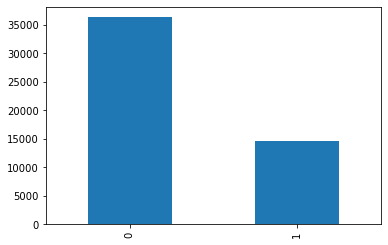

In [15]:
# Distribution of Churn
train.Churn.value_counts()[0:30].plot(kind='bar')
plt.show()

# Plotting Heatmap
Heatmap can be defined as a method of graphically representing numerical data where individual data points contained in the matrix are represented using different colors. 
The colors in the heatmap can denote the frequency of an event, the performance of various metrics in the data set, and so on. Different color schemes are selected by varying businesses to present the data they want to be plotted on a heatmap [[2](https://vwo.com/blog/heatmap/)].

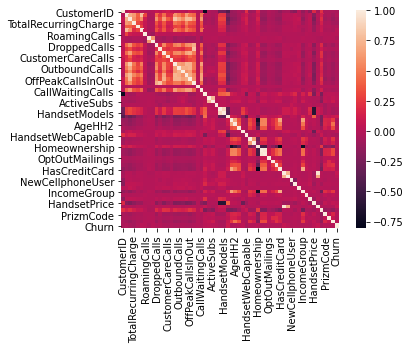

In [16]:
train = train[['CustomerID','MonthlyRevenue','MonthlyMinutes','TotalRecurringCharge','DirectorAssistedCalls','OverageMinutes',
         'RoamingCalls','PercChangeMinutes','PercChangeRevenues','DroppedCalls','BlockedCalls','UnansweredCalls','CustomerCareCalls',
         'ThreewayCalls','ReceivedCalls','OutboundCalls','InboundCalls','PeakCallsInOut','OffPeakCallsInOut','DroppedBlockedCalls','CallForwardingCalls'
         ,'CallWaitingCalls','MonthsInService','UniqueSubs','ActiveSubs','ServiceArea','Handsets','HandsetModels',              
'CurrentEquipmentDays','AgeHH1','AgeHH2','ChildrenInHH','HandsetRefurbished','HandsetWebCapable','TruckOwner','RVOwner','Homeownership','BuysViaMailOrder','RespondsToMailOffers','OptOutMailings',          
'NonUSTravel','OwnsComputer','HasCreditCard','RetentionCalls','RetentionOffersAccepted','NewCellphoneUser',          
'NotNewCellphoneUser','ReferralsMadeBySubscriber','IncomeGroup','OwnsMotorcycle','AdjustmentsToCreditRating', 
'HandsetPrice','MadeCallToRetentionTeam','CreditRating','PrizmCode','Occupation','MaritalStatus','Churn']] #Subsetting the data
cor = train.corr() #Calculate the correlation of the above variables
sns.heatmap(cor, square = True) #Plot the correlation as heat map

As you can see above, we obtain the heatmap of correlation among the variables. The color palette in the side represents the amount of correlation among the variables. The lighter shade represents a high correlation. Here appear important variables (customer churn behavior):
1. TotalRecurringCharge
1. RoamingCalls
1. DroppedCalls
1. CustomerCareCalls
1. OutboundCalls
1. OffPeakCallsInOut
1. CallWaitingCalls
1. ActiveSubs
1. HandsetModels
1. AgeHH2
1. HandsetWebCapable
1. Homeownership
1. OptOutMailings
1. HasCreditCard
1. NewCellphoneUser
1. IncomeGroup
1. HandsetPrice
1. PrizmCode

# SPLITING DATA

Data for training and testing
To select a set of training data that will be input in the Machine Learning algorithm, to ensure that the classification algorithm training can be generalized well to new data. For this study using a sample size of 30%, assumed it ideal ratio between training and testing

In [17]:
from sklearn.model_selection import train_test_split
Y = train['Churn']
X = train.drop(columns=['Churn'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=9)

In [18]:
print('X train shape: ', X_train.shape)
print('Y train shape: ', Y_train.shape)
print('X test shape: ', X_test.shape)
print('Y test shape: ', Y_test.shape)

X train shape:  (35732, 57)
Y train shape:  (35732,)
X test shape:  (15315, 57)
Y test shape:  (15315,)


## 1. Random forest classification

Based on the previous classification method, random forest is a supervised learning algorithm that creates a forest randomly. This forest, is a set of decision trees, most of the times trained with the bagging method. The essential idea of bagging is to average many noisy but approximately impartial models, and therefore reduce the variation. Each tree is constructed using the following algorithm:

* Let $N$ be the number of test cases, $M$ is the number of variables in the classifier.
* Let $m$ be the number of input variables to be used to determine the decision in a given node; $m<M$.
* Choose a training set for this tree and use the rest of the test cases to estimate the error.
* For each node of the tree, randomly choose $m$ variables on which to base the decision. Calculate the best partition of the training set from the $m$ variables.

For prediction a new case is pushed down the tree. Then it is assigned the label of the terminal node where it ends. This process is iterated by all the trees in the assembly, and the label that gets the most incidents is reported as the prediction. We define the number of trees in the forest in 100. 

In [19]:
from sklearn.ensemble import RandomForestClassifier

# We define the model
rfcla = RandomForestClassifier(n_estimators=100,random_state=9,n_jobs=-1)

# We train model
rfcla.fit(X_train, Y_train)

# We predict target values
Y_predict5 = rfcla.predict(X_test)

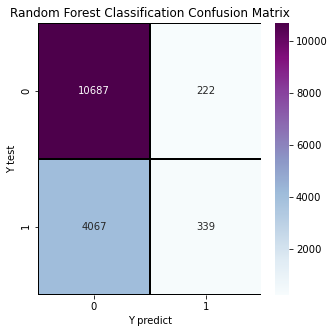

In [20]:
# The confusion matrix
rfcla_cm = confusion_matrix(Y_test, Y_predict5)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(rfcla_cm, annot=True, linewidth=0.7, linecolor='black', fmt='g', ax=ax, cmap="BuPu")
plt.title('Random Forest Classification Confusion Matrix')
plt.xlabel('Y predict')
plt.ylabel('Y test')
plt.show()

In [21]:
# Test score
score_rfcla = rfcla.score(X_test, Y_test)
print(score_rfcla)

0.7199477636304277


## 2. Naive bayes classification

The naive Bayesian classifier is a probabilistic classifier based on Bayes' theorem with strong independence assumptions between the features. Thus, using Bayes theorem $\left(P(X|Y)=\frac{P(Y|X)P(X)}{P(Y)}\right)$, we can find the probability of $X$ happening, given that $Y$ has occurred. Here, $Y$ is the evidence and $X$ is the hypothesis. The assumption made here is that the presence of one particular feature does not affect the other (the predictors/features are independent). Hence it is called naive. In this case we will assume that we assume the values are sampled from a Gaussian distribution and therefore we consider a Gaussian Naive Bayes.

In [22]:
from sklearn.naive_bayes import GaussianNB

# We define the model
nbcla = GaussianNB()

# We train model
nbcla.fit(X_train, Y_train)

# We predict target values
Y_predict3 = nbcla.predict(X_test)

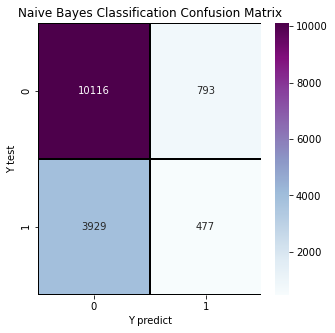

In [23]:
# The confusion matrix
nbcla_cm = confusion_matrix(Y_test, Y_predict3)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(nbcla_cm, annot=True, linewidth=0.7, linecolor='black', fmt='g', ax=ax, cmap="BuPu")
plt.title('Naive Bayes Classification Confusion Matrix')
plt.xlabel('Y predict')
plt.ylabel('Y test')
plt.show()

In [24]:
# Test score
score_nbcla = nbcla.score(X_test, Y_test)
print(score_nbcla)

0.6916748285994123


# Comparison of classification techniques

# Test score


In [25]:
Testscores = pd.Series([score_rfcla,score_nbcla, ], 
                        index=['Random Forest Score','Naive Bayes Score' ]) 
print(Testscores)

Random Forest Score    0.719948
Naive Bayes Score      0.691675
dtype: float64


# ROC Curve
is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.

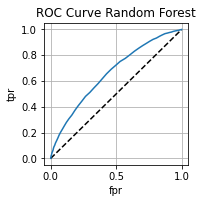

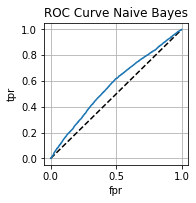

In [26]:
from sklearn.metrics import roc_curve
# Random Forest Classification
Y_predict5_proba = rfcla.predict_proba(X_test)
Y_predict5_proba = Y_predict5_proba[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_predict5_proba)
plt.subplot(331)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC Curve Random Forest')
plt.grid(True)
plt.subplots_adjust(top=2, bottom=0.08, left=0.10, right=1.4, hspace=0.45, wspace=0.45)
plt.show()

# Naive Bayes Classification
Y_predict3_proba = nbcla.predict_proba(X_test)
Y_predict3_proba = Y_predict3_proba[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_predict3_proba)
plt.subplot(332)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC Curve Naive Bayes')
plt.grid(True)
plt.subplots_adjust(top=2, bottom=0.08, left=0.10, right=1.4, hspace=0.45, wspace=0.45)
plt.show()

# Conclusion

Random Forest perform better than Naive Bayes. Random Forest can handle categorical features very well and it can handle high dimensional spaces as well as a large number of training examples. I guess Naive Bayes is not good enough to represent complex behavior.